In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [126]:
# Create random values in x with 200 rows & 1 colum
x=6*np.random.rand(200,1)-3

In [128]:
# y = 0.8x^2+0.9x+2
y=0.8*x**2+ 0.9 * x + 2 + np.random.randn(200,1)



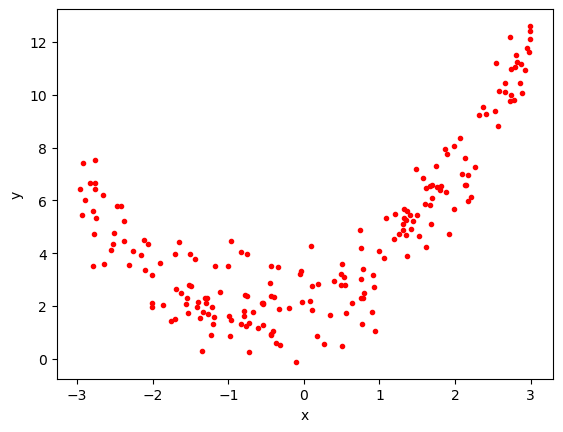

In [48]:
plt.plot(x,y,'r.') # . is used for plotting dots rather than lines & r = red color
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [130]:
# Train test spli
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [132]:
# Appling linear regression
lr=LinearRegression()

In [134]:
lr.fit(x_train,y_train)

LinearRegression()

In [136]:
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.2736623007961676

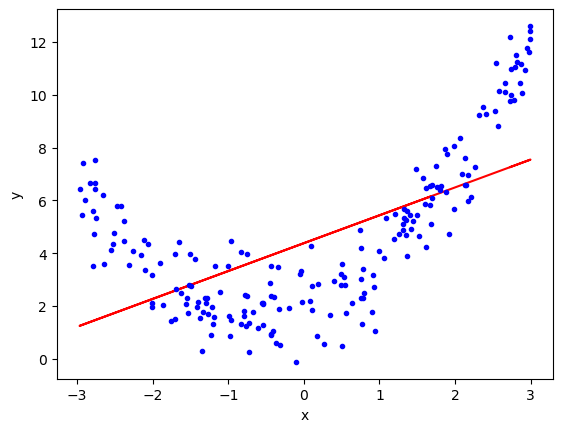

In [62]:
# This graph is plot for how our prediction line go/passing on the data
plt.plot(x_train,lr.predict(x_train),color='r') #  for line
plt.plot(x,y,'.b')
plt.xlabel("x")
plt.ylabel('y')
plt.show()

# Applying Polynomial Regression

In [65]:
# Degree =2 it means polynomial terms up to x^2 (second degree)
poly= PolynomialFeatures(degree=2,include_bias=True)

x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)

In [73]:
print(x_train[0])
print(x_train_trans[0])

[1.67784716]
[1.         1.67784716 2.8151711 ]


In [75]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [77]:
y_pred=lr.predict(x_test_trans)

In [79]:
r2_score(y_test,y_pred)

0.8813184692671419

In [81]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.91936731 0.80514774]]
[2.04845989]


In [101]:
# Create new higher order x^2,x^3 features
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new= lr.predict(x_new_poly)


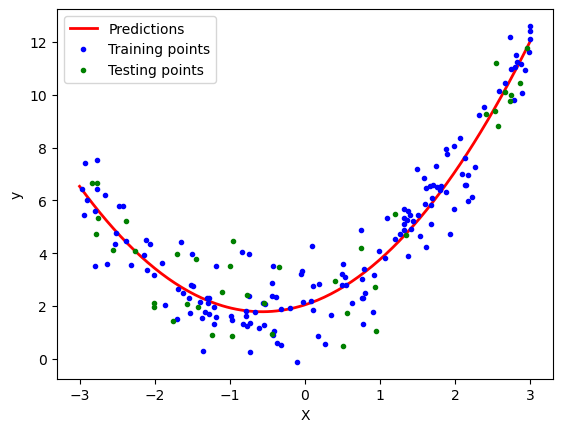

In [103]:
plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# created own polynomial function

In [142]:

def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(x, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

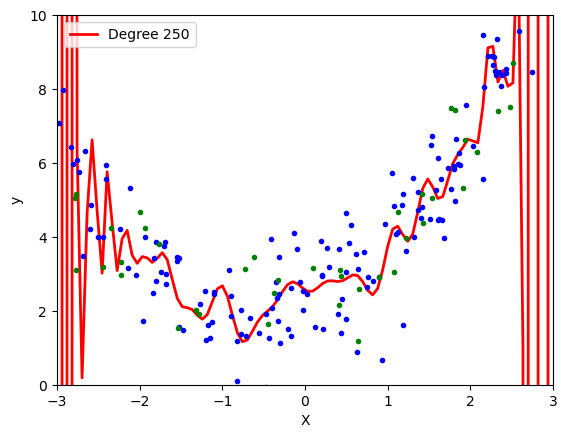

In [146]:
polynomial_regression(250)

# Applying Gradient Descent

C:\Users\sanke\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


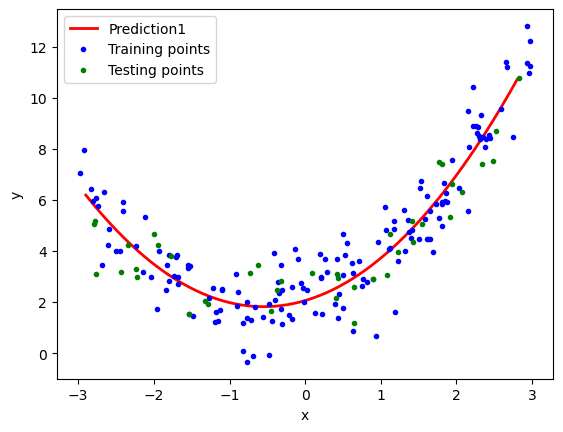

In [157]:
poly = PolynomialFeatures(degree=2)

x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)

sgd=SGDRegressor(max_iter=100)
sgd.fit(x_train_trans,y_train)

x_new=np.linspace(-2.9,2.8,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new=sgd.predict(x_new_poly)

y_pred=sgd.predict(x_test_trans)
r2=round(r2_score(y_test,y_pred))
plt.plot(x_new,y_new,"r-",linewidth=2,label="Prediction" + str(r2))
plt.plot(x_train,y_train,"b.",label="Training points")
plt.plot(x_test,y_test,"g.",label="Testing points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


0